In [1]:
# %reset
import numpy as np
import sys,os
import readgadget
import MAS_library as MASL
import pickle as pk
import readfof
import matplotlib
import h5py as h5
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline



%load_ext Cython

    
    



In [2]:
%load_ext Cython



The Cython extension is already loaded. To reload it, use:
  %reload_ext Cython


In [3]:
%%cython

cimport numpy as np
cpdef void NGP_mass(np.float32_t[:,:] pos, np.float32_t[:] logM, np.float32_t[:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef int index[3]

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if gridM[index[0],index[1],index[2], jM] == 0:
                gridM[index[0],index[1],index[2], jM] = logM[i]
                break
            else:
                pass
        
        
        
        

In file included from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarraytypes.h:1909:0,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from /u/spandey3/.cache/ipython/cython/_cython_magic_4eebac4d94def1f14bcf2e111de593d3.c:778:
/u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
 #warning "Using deprecated NumPy API, disable it with " \
  ^~~~~~~


In [4]:
%%cython
cimport numpy as np
cpdef void NGP_xyz(np.float32_t[:,:] pos, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                # gridM[index[0],index[1],index[2], jM, 3] = logM[i]
                break
            else:
                pass


            

In file included from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarraytypes.h:1909:0,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from /u/spandey3/.cache/ipython/cython/_cython_magic_8ed04b31a3ff88d31df5c943b256f851.c:779:
/u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
 #warning "Using deprecated NumPy API, disable it with " \
  ^~~~~~~
/u/spandey3/.cache/ipython/cython/_cython_magic_8ed04b31a3ff88d31df5c943b256f851.c: In function ‘__pyx_pw_46_cython_magic_8ed04b31a3ff88d31df5c943b256f851_1NGP_xyz’:
/u/spandey3/.cache/ipython/cython/_cython_magic_8ed04b31a3ff88d31df5c943b256f

In [5]:

%%cython
cimport numpy as np
cpdef void NGP_xyzM(np.float32_t[:,:] pos, np.float32_t[:] logM, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                gridM[index[0],index[1],index[2], jM, 3] = logM[i]
                break
            else:
                pass


            
            
            

In file included from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarraytypes.h:1909:0,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from /u/spandey3/.cache/ipython/cython/_cython_magic_22670bd810716ff59fbecba41f544cf3.c:780:
/u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
 #warning "Using deprecated NumPy API, disable it with " \
  ^~~~~~~
/u/spandey3/.cache/ipython/cython/_cython_magic_22670bd810716ff59fbecba41f544cf3.c: In function ‘__pyx_pw_46_cython_magic_22670bd810716ff59fbecba41f544cf3_1NGP_xyzM’:
/u/spandey3/.cache/ipython/cython/_cython_magic_22670bd810716ff59fbecba41f54

In [6]:
%%cython
cimport numpy as np
cpdef void NGP_xyz_vxvyvz(np.float32_t[:,:] pos, np.float32_t[:, :] vel, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
                
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0) and (gridM[index[0],index[1],index[2], jM, 4] == 0) and (gridM[index[0],index[1],index[2], jM, 5] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                gridM[index[0],index[1],index[2], jM, 3] = vel[i,0]
                gridM[index[0],index[1],index[2], jM, 4] = vel[i,1]
                gridM[index[0],index[1],index[2], jM, 5] = vel[i,2]
                break
            else:
                pass


            
            
            

In file included from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarraytypes.h:1909:0,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from /u/spandey3/.cache/ipython/cython/_cython_magic_de41bbf4dcbd80d49c3b2bc8c881856f.c:781:
/u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
 #warning "Using deprecated NumPy API, disable it with " \
  ^~~~~~~
/u/spandey3/.cache/ipython/cython/_cython_magic_de41bbf4dcbd80d49c3b2bc8c881856f.c: In function ‘__pyx_pw_46_cython_magic_de41bbf4dcbd80d49c3b2bc8c881856f_1NGP_xyz_vxvyvz’:
/u/spandey3/.cache/ipython/cython/_cython_magic_de41bbf4dcbd80d49c3b2b

In [7]:
%%cython
cimport numpy as np
cpdef void NGP_xyz_prop(np.float32_t[:,:] pos, np.float32_t[:, :] prop, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM, coord_prop
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    coord_prop = prop.shape[1]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
                
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
                
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0) and (gridM[index[0],index[1],index[2], jM, 4] == 0) and (gridM[index[0],index[1],index[2], jM, 5] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                for k in range(coord_prop):
                    gridM[index[0],index[1],index[2], jM, 3+k] = prop[i,k]
                break
            else:
                pass

            

In file included from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarraytypes.h:1909:0,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from /u/spandey3/.cache/ipython/cython/_cython_magic_c91f0e72b7043881e9359ddbb1c14892.c:782:
/u/spandey3/gotham/lib/python3.10/site-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
 #warning "Using deprecated NumPy API, disable it with " \
  ^~~~~~~
/u/spandey3/.cache/ipython/cython/_cython_magic_c91f0e72b7043881e9359ddbb1c14892.c: In function ‘__pyx_pw_46_cython_magic_c91f0e72b7043881e9359ddbb1c14892_1NGP_xyz_prop’:
/u/spandey3/.cache/ipython/cython/_cython_magic_c91f0e72b7043881e9359ddb

In [12]:
LHid = 0
snap = '090'
group_catalog = f'/work/hdd/bdne/spandey3/camels_tng/hydro/LH/LH_{LHid}/groups_090.hdf5'
photo_catalog = f'/work/hdd/bdne/spandey3/camels_tng/hydro/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{LHid}_photometry.hdf5'

# open the catalogue
with h5.File(photo_catalog, "r") as hf:
    subhalo_index = np.array(hf[f"snap_{snap}/SubhaloIndex"][:], dtype=int)
    g_band = np.log10(hf[f"snap_{snap}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
    r_band = np.log10(hf[f"snap_{snap}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
    i_band = np.log10(hf[f"snap_{snap}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])

# Read the stellar masses of the subhalos/galaxies
with h5.File(group_catalog, "r") as hf:
   M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
   pos = hf['Subhalo/SubhaloPos'][:]/1000.

# Filter stellar masses using the subhalo index
M_star = M_star[subhalo_index]
pos = pos[subhalo_index]


In [13]:
pos_h_truth = pos
prop_truth_all = np.stack((g_band, r_band, i_band, M_star)).T
prop_min = np.array([25, 25, 25, 7.5])
prop_max = np.array([30, 30, 30, 11])



In [14]:
pos_h_truth.shape, prop_truth_all.shape, prop_min.shape, prop_max.shape


((523, 3), (523, 4), (4,), (4,))

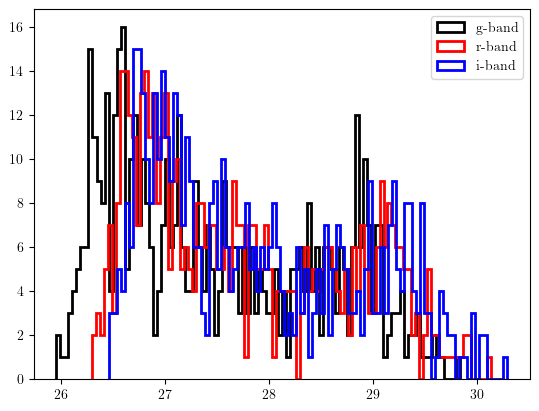

In [10]:
# np.amin(np.log10(M_star)), np.amax(np.log10(M_star))
# len(M_star), len(g_band)
pl.figure()
_ = pl.hist(np.log10(g_band), bins=100, histtype='step', color='k', lw=2, label='g-band')
_ = pl.hist(np.log10(r_band), bins=100, histtype='step', color='r', lw=2, label='r-band')
_ = pl.hist(np.log10(i_band), bins=100, histtype='step', color='b', lw=2, label='i-band')
# _ = pl.hist(np.log10(z_band), bins=100, histtype='step', color='b', lw=2, label='z-band')
pl.legend()
pl.show()



In [ ]:
# group_catalog = f'/projects/bdne/spandey3/GOTHAM/prep_data/groups_090.hdf5'
# with h5.File(group_catalog, "r") as hf:
#     print(hf['Subhalo'].keys())
#     M_star = hf['Subhalo/SubhaloMassType'][:,4]*1e10
#     pos_sh = hf['Subhalo/SubhaloPos'][:]/1000.



# indsel = np.where(M_star>1e8)[0]
# M_star = M_star[indsel]
# pos_sh = pos_sh[indsel]

# print(M_star.shape, pos_sh.shape)


# # sfr.shape, pos.shape

# df = h5.File('/scratch/bdne/spandey3/camels_tng/DMO/CV/CV_0/snapshot_090.hdf5','r')
# df['PartType1']['Coordinates'][()].shape



<KeysViewHDF5 ['SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloBfldDisk', 'SubhaloBfldHalo', 'SubhaloCM', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloGasMetallicityMaxRad', 'SubhaloGasMetallicitySfr', 'SubhaloGasMetallicitySfrWeighted', 'SubhaloGrNr', 'SubhaloHalfmassRad', 'SubhaloHalfmassRadType', 'SubhaloIDMostbound', 'SubhaloLen', 'SubhaloLenType', 'SubhaloMass', 'SubhaloMassInHalfRad', 'SubhaloMassInHalfRadType', 'SubhaloMassInMaxRad', 'SubhaloMassInMaxRadType', 'SubhaloMassInRad', 'SubhaloMassInRadType', 'SubhaloMassType', 'SubhaloParent', 'SubhaloPos', 'SubhaloSFR', 'SubhaloSFRinHalfRad', 'SubhaloSFRinMaxRad', 'SubhaloSFRinRad', 'SubhaloSpin', 'SubhaloStarMetalFractions', 'SubhaloStarMetalFractionsHalfRad', 'SubhaloStarMetalFractionsMaxRad', 'SubhaloStarMetallicity', 'SubhaloStarMetallicityHalfRad', '

(16777216, 3)

In [9]:
# vel_m_truth.shape, pos_m_truth.shape
def process_DMO_snaps(snap_fname, norm_delta = 100, norm_vel = 1000, BoxSize = 25., grid = 8, grid_sbox = 32, npart_test = 128**3):
    import numpy as np
    import h5py as h5
    np.random.seed(0)
    # root = '/scratch/bdne/spandey3/camels_tng/DMO/CV'
    # # z = {4:0, -1: 99, 3:0.5}[snapnum]
    # # df = h5.File(f'{root}/CV_{isim_fid}/snapshot_090.hdf5', 'r')            
    df = h5.File(snap_fname, 'r')                
    pos = df['PartType1']['Coordinates'][()]/1000.
    vel = df['PartType1']['Velocities'][()]
    ids = np.arange(len(pos))
    # get random permutation of indices of particles:
    arg_rand_perm = np.random.permutation(len(pos))

    # npart_test = 128**3
    ind = arg_rand_perm[:npart_test]
    pos_m_truth = pos[ind]
    vel_m_truth = vel[ind]
    ids_m_truth = ids[ind]

    # npart_test = len(pos_m_truth)
    # pos_m_truth = pos
    # vel_m_truth = vel
    # ids_m_truth = ids


    # BoxSize = 25.
    # grid = 8
    # nMax_m = 32
    Npart = np.float32(np.zeros((grid, grid, grid)))
    MASL.NGP(np.float32(pos_m_truth), Npart, BoxSize)

    nMax_h = 6000

    dfpart_ngp_wxyz_vxvyvz = np.float32(np.zeros((grid, grid, grid, nMax_h, 6)))
    NGP_xyz_vxvyvz(np.float32(pos_m_truth), np.float32(vel_m_truth), dfpart_ngp_wxyz_vxvyvz, BoxSize)

    from tqdm import tqdm
          
    # norm_vel = 1000    
    # grid_sbox = 32
    MAS = 'NGP'
    verbose = False
    delta_box_all = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 6))
    # vel_box_all = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 3))
    for j1 in tqdm(range(grid)):
        for j2 in range(grid):
            for j3 in range(grid):
                
                if j1 == 0:
                    jn1 = grid - 1
                else:
                    jn1 = j1 - 1
                if j1 == grid - 1:
                    jp1 = 0
                else:
                    jp1 = j1 + 1

                jp1_all = [jn1, j1, jp1]

                if j2 == 0:
                    jn2 = grid - 1
                else:
                    jn2 = j2 - 1

                if j2 == grid - 1:
                    jp2 = 0
                else:
                    jp2 = j2 + 1

                jp2_all = [jn2, j2, jp2]

                if j3 == 0:
                    jn3 = grid - 1
                else:
                    jn3 = j3 - 1

                if j3 == grid - 1:
                    jp3 = 0
                else:
                    jp3 = j3 + 1

                jp3_all = [jn3, j3, jp3]

                coord_add_sign = [-1,0,1]
                all_part = []
                all_part_vel = []
                for i1 in range(3):
                    for i2 in range(3):
                        for i3 in range(3):
                            all_part_here = dfpart_ngp_wxyz_vxvyvz[jp1_all[i1],jp2_all[i2],jp3_all[i3],:,:3]
                            all_part_vel_here = dfpart_ngp_wxyz_vxvyvz[jp1_all[i1],jp2_all[i2],jp3_all[i3],:,3:]
                            indpos = np.where(all_part_here[:,0] != 0)[0]
                            all_part_here = all_part_here[indpos,:]
                            all_part_vel_here = all_part_vel_here[indpos,:]
                            all_part_here[:,0] = all_part_here[:,0] + coord_add_sign[i1]*BoxSize/(grid)
                            all_part_here[:,1] = all_part_here[:,1] + coord_add_sign[i2]*BoxSize/(grid)
                            all_part_here[:,2] = all_part_here[:,2] + coord_add_sign[i3]*BoxSize/(grid)

                            if len(all_part) == 0:
                                all_part = all_part_here
                                all_part_vel = all_part_vel_here
                            else:
                                all_part = np.vstack((all_part, all_part_here))
                                all_part_vel = np.vstack((all_part_vel, all_part_vel_here))



                box_size_sbox = BoxSize/(2*grid)
                all_part0_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
                all_part0 = all_part[all_part0_sel]
                delta_sbox0 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part0 + box_size_sbox, delta_sbox0, (2*box_size_sbox), MAS, verbose=verbose)
                nbar0 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox0 /= nbar0
                delta_sbox0 /= norm_delta

                pvel = all_part_vel[all_part0_sel]
                ppos = all_part0 + box_size_sbox
                rho_m_orig = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(ppos, rho_m_orig, (2*box_size_sbox), 'CIC', verbose=False)
                mom_m_x_orig = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)                
                MASL.MA(ppos, mom_m_x_orig, (2*box_size_sbox), 'CIC', verbose=False, W=pvel[:,0].astype(np.float32))
                mom_m_y_orig = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)                
                MASL.MA(ppos, mom_m_y_orig, (2*box_size_sbox), 'CIC', verbose=False, W=pvel[:,1].astype(np.float32))
                mom_m_z_orig = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)               
                MASL.MA(ppos, mom_m_z_orig, (2*box_size_sbox), 'CIC', verbose=False, W=pvel[:,2].astype(np.float32))                
                vel_m_x_orig = mom_m_x_orig/rho_m_orig
                vel_m_y_orig = mom_m_y_orig/rho_m_orig
                vel_m_z_orig = mom_m_z_orig/rho_m_orig
                # at voxels with non-finite values, set velocities to zero:
                vel_m_x_orig[~np.isfinite(vel_m_x_orig)] = 0.0
                vel_m_y_orig[~np.isfinite(vel_m_y_orig)] = 0.0
                vel_m_z_orig[~np.isfinite(vel_m_z_orig)] = 0.0
                # divide out by 1000.:
                vel_m_x_orig /= norm_vel
                vel_m_y_orig /= norm_vel
                vel_m_z_orig /= norm_vel

                box_size_sbox = 2*BoxSize/(2*grid)
                all_part1_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
                all_part1 = all_part[all_part1_sel]
                delta_sbox1 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part1 + box_size_sbox, delta_sbox1, (2*box_size_sbox), MAS, verbose=verbose)
                nbar1 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox1 /= nbar1
                delta_sbox1 /= norm_delta


                box_size_sbox = 3*BoxSize/(2*grid)
                all_part2 = all_part
                delta_sbox2 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part2 + box_size_sbox, delta_sbox2, (2*box_size_sbox), MAS, verbose=verbose)
                nbar2 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox2 /= nbar2
                delta_sbox2 /= norm_delta

                delta_sbox_all = np.stack((delta_sbox0, delta_sbox1, delta_sbox2, vel_m_x_orig, vel_m_y_orig, vel_m_z_orig))

                # move first axis to last:
                delta_sbox_all = np.moveaxis(delta_sbox_all, 0, -1)

                delta_box_all[j1,j2,j3] = delta_sbox_all

    delta_box_all_squeezed = np.reshape(delta_box_all, (grid*grid*grid, grid_sbox, grid_sbox, grid_sbox, 6))

    return delta_box_all_squeezed



In [11]:
from tqdm import tqdm
# isim_fid_array = np.arange(0, 1000)
isim_fid_array = np.arange(990, 1000)

nrand_sel_box = 512

# snap_array = np.array([90])
for isim_fid in tqdm(isim_fid_array):
    snapnum = 90
    snap_dir_base = f'/work/hdd/bdne/spandey3/camels_tng/hydro/'
    group_catalog = f'{snap_dir_base}/LH/LH_{isim_fid}/groups_0{snapnum}.hdf5'
    photo_catalog = f'{snap_dir_base}/Photometry/IllustrisTNG/L25n256/LH/IllustrisTNG_LH_{isim_fid}_photometry.hdf5'
    # open the catalogue
    with h5.File(photo_catalog, "r") as hf:
        subhalo_index = np.array(hf[f"snap_0{snapnum}/SubhaloIndex"][:], dtype=int)
        g_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.g"][:])
        r_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.r"][:])
        i_band = np.log10(hf[f"snap_0{snapnum}/BC03/photometry/luminosity/attenuated/SLOAN/SDSS.i"][:])

    # Read the stellar masses of the subhalos/galaxies
    with h5.File(group_catalog, "r") as hf:
        M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.01) # Stellar masses in Msun/h
        pos = hf['Subhalo/SubhaloPos'][:]/1000.

    # Filter stellar masses using the subhalo index
    M_star = M_star[subhalo_index]
    pos = pos[subhalo_index]

    pos_h_truth = pos
    prop_truth_all = np.stack((g_band, r_band, i_band, M_star)).T
    prop_min = np.array([25, 25, 25, 7.5])
    prop_max = np.array([30, 30, 30, 11])

    norm_delta = 100,
    norm_vel = 1000,
    BoxSize = 25.
    grid = 8
    grid_sbox = 32
    npart_test = 128**3
    nMax_h = 20
    nvocab = 64

    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/wSDSS_photometry'
    savefname = f'{sdir}/subhalo_WITHOUT_density3Dgrid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_wSDSS_photometry.pkl'
    # check if the file already exists:
    if os.path.exists(savefname):
        print(f'File {savefname} already exists. Skipping...')
        # return
    else:

        sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
        Mstar_cut = 8
        savefname_DENSITY = f'{sdir}/subhalo_density3Dgrid_{grid_sbox}_isim_{isim_fid}_nrandsubsel_{nrand_sel_box}_nvocab{nvocab}_lgMmin_{Mstar_cut}.pkl'
        print(savefname_DENSITY)
        # check if the file already exists:
        if os.path.exists(savefname_DENSITY):
            # print(f'File for density already exists. Opening the random selection')
            # return
            saved = pk.load(open(savefname_DENSITY, 'rb'))
            rand_sel = saved['rand_sel']
        else:
            print('running new density estimate')
            root = '/scratch/bdne/spandey3/camels_tng/DMO/LH'
            snapnums = [90, 84, 78, 70, 60]
            # z = {4:0, -1: 99, 3:0.5}[snapnum]
            delta_box_all_squeezed = []
            for snapnum in snapnums:
                print(snapnum)
                snap_fname = f'{root}/LH_{isim_fid}/snapshot_0{snapnum}.hdf5'
                delta_box_all_squeezed_js = process_DMO_snaps(snap_fname, norm_delta = norm_delta, norm_vel = norm_vel, BoxSize = BoxSize, grid = grid, grid_sbox = grid_sbox, npart_test = npart_test)
                if len(delta_box_all_squeezed) == 0:
                    delta_box_all_squeezed = delta_box_all_squeezed_js
                else:
                    delta_box_all_squeezed = np.concatenate((delta_box_all_squeezed, delta_box_all_squeezed_js), axis=-1)
                # print(delta_box_all_squeezed.shape)
        # elif grid == 128:
        # BoxSize = 25.
        # grid = 8
        # nMax_h = 42
        dim_pos = pos_h_truth.shape[1]
        dim_prop = prop_truth_all.shape[1]
        dfhalo_ngp_wxyz_props = np.float32(np.zeros((grid, grid, grid, nMax_h, dim_pos + dim_prop)))
        NGP_xyz_prop(np.float32(pos_h_truth), np.float32(prop_truth_all), dfhalo_ngp_wxyz_props, BoxSize)


        # dfhalo_ngp_wxyzM_squeezed = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))
        Nhalos_truth = np.float32(np.zeros((grid, grid, grid)))
        MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)

        # sort the galaxies based on their stellar mass
        prop_halos_argsort = np.flip(np.argsort(dfhalo_ngp_wxyz_props[:,:,:,:,-1], axis=-1), axis=-1)
        xmin = BoxSize/grid/2
        # lgMin = np.log10(Mmin_cut)
        # lgMax = 15.5
        dfhalo_ngp_xyzM_sorted_scaled = np.zeros_like(dfhalo_ngp_wxyz_props)
        for i1 in range(grid):
            for i2 in range(grid):
                for i3 in range(grid):

                    for jp in range(dim_pos):
                        dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jp] = dfhalo_ngp_wxyz_props[i1, i2, i3, prop_halos_argsort[i1, i2, i3], jp]
                        indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jp] != 0.0)[0]
                        dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jp] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jp] + xmin)/(2*xmin)

                    for jp in range(dim_prop):
                        dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, dim_pos + jp] = dfhalo_ngp_wxyz_props[i1, i2, i3, prop_halos_argsort[i1, i2, i3], dim_pos + jp]
                        indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, dim_pos + jp] != 0.0)[0]
                        dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, dim_pos + jp] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, dim_pos + jp] - prop_min[jp])/(prop_max[jp] - prop_min[jp])

        indzeros = np.where(dfhalo_ngp_xyzM_sorted_scaled == 0.0)
        dfhalo_ngp_xyzM_sorted_scaled[indzeros] = -1.0


        bins_digitize = np.linspace(-1e-3, 1, nvocab)
        bins_digitize = np.insert(bins_digitize, 0, -1)
        dfhalo_ngp_xyzM_sorted_scaled_digitized = np.digitize(dfhalo_ngp_xyzM_sorted_scaled, bins_digitize)

        start_token = 0
        pad_token = 1
        end_token = nvocab + 1
        space_token = nvocab + 2
        max_sentence_length = 1 + nMax_h*(dim_pos+dim_prop) + 1 + (nMax_h-1)
        dfhalo_ngp_xyzM_tokenized = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int16) + end_token

        dfhalo_ngp_xyzM_tokenized[..., 0] = start_token
        # for jh in range(nMax_h):
        jh = 1
        word_length = 1 + dim_pos + dim_prop
        while jh < (word_length)*nMax_h:
            # if dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh, 0] > 1:
            for jp in range(dim_pos + dim_prop):
                dfhalo_ngp_xyzM_tokenized[..., jh + jp] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//word_length, jp]
            if jh//word_length < nMax_h - 1:
                dfhalo_ngp_xyzM_tokenized[..., jh + word_length-1] = space_token
            jh += word_length



        dfhalo_ngp_xyzM_tokenized_padded_ended = np.copy(dfhalo_ngp_xyzM_tokenized)
        for i1 in range(grid):
            for i2 in range(grid):
                for i3 in range(grid):
                    ind1 = np.where(dfhalo_ngp_xyzM_tokenized[i1, i2, i3,:] == 1)[0]
                    try:
                        ind1 = ind1[0]
                        if ind1 == 1:
                            dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1] = end_token
                            dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1+1:] = pad_token
                        else:
                            dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token
                            dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1:] = pad_token
                    except:
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token

        dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed = np.reshape(dfhalo_ngp_xyzM_tokenized_padded_ended, (grid*grid*grid, max_sentence_length))
        # dfhalo_ngp_wxyzM_flatten = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))
        Nhalos_truth_flatten = np.reshape(Nhalos_truth, (grid*grid*grid,))
        if not os.path.exists(savefname_DENSITY):
            rand_sel = np.sort(np.random.permutation(len(Nhalos_truth_flatten))[:nrand_sel_box])

        saved = {'dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed':dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.astype(np.int16)[rand_sel,...],
                # 'dfhalo_ngp_wxyzM': dfhalo_ngp_wxyzM.astype(np.float32),
                'Nhalos_truth_flatten': Nhalos_truth_flatten.astype(np.int16)[rand_sel],
                # 'delta_box_all_squeezed': delta_box_all_squeezed.astype(np.float32)[rand_sel, ...],
                'rand_sel': rand_sel,
                'nvocab_total': nvocab + 3,
                'max_sentence_length': max_sentence_length,
                'grid': grid,
                'grid_sbox': grid_sbox,
                'nMax_h': nMax_h,
                'BoxSize': BoxSize,
                'prop_min': prop_min,
                'prop_max': prop_max,
                'xmin': xmin,
                'norm_delta': norm_delta,
                'norm_vel': norm_vel,
                'start_token': start_token,
                'pad_token': pad_token,
                'end_token': end_token,
                'space_token': space_token
                }
        pk.dump(saved, open(savefname, 'wb'))
        # return

        # pk.dump(saved, open(f'/mnt/home/spandey/ceph/GOTHAM/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_{grid_sbox}_isim_{isim_fid}_snap_{snapnum}_nvocab64_Mmin_1e13p5.pkl', 'wb'))




  0%|          | 0/10 [00:00<?, ?it/s]

/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/subhalo_density3Dgrid_32_isim_990_nrandsubsel_512_nvocab64_lgMmin_8.pkl


 10%|█         | 1/10 [00:06<01:01,  6.83s/it]

/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/subhalo_density3Dgrid_32_isim_991_nrandsubsel_512_nvocab64_lgMmin_8.pkl


 20%|██        | 2/10 [00:11<00:45,  5.70s/it]

...

 80%|████████  | 8/10 [00:42<00:10,  5.44s/it]

/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/subhalo_density3Dgrid_32_isim_998_nrandsubsel_512_nvocab64_lgMmin_8.pkl


 90%|█████████ | 9/10 [00:45<00:04,  4.43s/it]

/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/subhalo_density3Dgrid_32_isim_999_nrandsubsel_512_nvocab64_lgMmin_8.pkl


100%|██████████| 10/10 [00:47<00:00,  4.77s/it]


In [26]:
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[6]

# Nhalos_truth_flatten

array([ 0, 16, 52, 49, 56, 59, 60, 60, 66, 18, 52, 49, 46, 48, 49, 43, 66,
       13, 53, 45, 20, 23, 24, 10, 65,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1], dtype=int16)

In [11]:
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[6]


array([ 0, 49, 60, 28, 55, 59, 61, 65, 66, 47, 52, 27, 48, 52, 54, 57, 66,
       48, 58, 27, 43, 47, 49, 46, 66, 49, 60, 27, 37, 41, 43, 41, 66, 46,
       46, 32, 44, 47, 48, 41, 66, 51, 60, 31, 34, 38, 40, 38, 66, 45, 58,
       26, 32, 37, 39, 35, 66, 52, 43, 23, 32, 36, 38, 31, 66, 48, 46, 36,
       32, 36, 38, 31, 66, 44, 59, 24, 31, 35, 37, 29, 66, 39, 61, 17, 29,
       33, 35, 27, 66, 46, 50, 27, 29, 33, 35, 27, 66, 51, 47, 31, 28, 31,
       33, 25, 66, 50, 44, 24, 25, 29, 31, 21, 66, 49, 46, 26, 24, 28, 30,
       20, 66, 40, 61, 27, 20, 24, 26, 15, 66, 50, 56, 23, 25, 27, 29, 13,
       66, 42, 50, 22, 20, 23, 25, 13, 66, 56, 57, 32, 23, 26, 27, 11, 66,
       45, 54, 24, 18, 21, 23, 10, 65], dtype=int16)

In [13]:
Nhalos_truth_flatten[rand_sel]


array([ 0.,  0.,  0.,  0.,  0.,  0.,  5.,  4.,  2.,  2.,  3.,  5.,  4.,
        0.,  4., 14.,  0., 14.,  2.,  0.,  0.,  0.,  3.,  0.,  1.,  1.,
        5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,
        0.,  0.,  0.,  2.,  0.,  1.,  0.,  1., 13.,  0.,  0.,  3.,  0.,
        0.,  0.,  0.,  0.,  7.,  7.,  0.,  2.,  0.,  0.,  0.,  3.],
      dtype=float32)

In [145]:
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.shape, Nhalos_truth_flatten.shape, delta_box_all_squeezed.shape


((512, 201), (512,), (512, 32, 32, 32, 30))

In [143]:
# all_part_vel
# pvel.shape, ppos.shape
# delta_box_all_squeezed.shape, Nhalos_truth_flatten.shape
# Nhalos_truth_flatten[np.random.randint(0, 512, 8)]
np.random.permutation(len(Nhalos_truth_flatten))[:8]


array([425, 483, 301, 112, 434, 274,  58, 292])

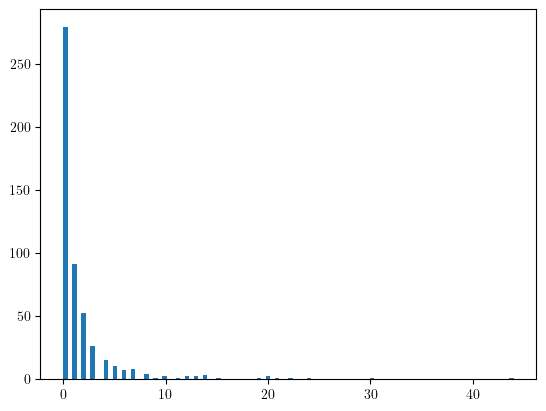

In [124]:
# # np.mean(delta_box_all_squeezed[...,0], axis=(1,2,3)).shape
# pl.figure()
# pl.scatter(np.mean(delta_box_all_squeezed[...,0], axis=(1,2,3)), Nhalos_truth_flatten, s=0.8)
# pl.yscale('log')
# # pl.xlim(0.0144, 0.0147)
# pl.show()

pl.figure()
_ = pl.hist(Nhalos_truth_flatten, bins=100)
pl.show()



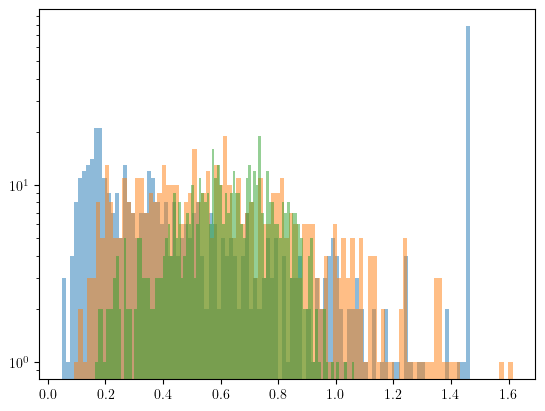

In [27]:
# # dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.shape
# # delta_box_all_squeezed.shape
# # np.mean(delta_box_all_squeezed[...,0], axis=(1,2,3)).shape
pl.figure()
_ = pl.hist(np.mean(delta_box_all_squeezed[...,0], axis=(1,2,3)), bins=100, alpha=0.5, label='density')
_ = pl.hist(np.mean(delta_box_all_squeezed[...,1], axis=(1,2,3)), bins=100, alpha=0.5, label='velocity')
_ = pl.hist(np.mean(delta_box_all_squeezed[...,2], axis=(1,2,3)), bins=100, alpha=0.5, label='potential')
pl.yscale('log')
pl.show()

# dmax = np.amax(np.mean(delta_box_all_squeezed[...,0]))
# print(dmax)
# np.where(np.mean(delta_box_all_squeezed[...,0]) == dmax)[0]



In [104]:
indsort = np.flip(np.argsort(np.mean(delta_box_all_squeezed[...,0], axis=(1,2,3))))
# print(indsort)
print(np.mean(delta_box_all_squeezed[...,0], axis=(1,2,3))[indsort])

# pl.figure()
# pl.imshow(np.sum(delta_box_all_squeezed[indsort[2],...,0], axis=0), origin='lower')
# pl.show()


[0.01464844 0.01464844 0.01464844 0.01464844 0.01464844 0.01464844
 0.01464844 0.01464844 0.01464844 0.01464844 0.01464844 0.01464844
 0.01464844 0.01464844 0.01464844 0.01464844 0.01464844 0.01464844
 0.01464844 0.01464844 0.01464844 0.01464844 0.01464844 0.01464844
 0.01464844 0.014646   0.014646   0.014646   0.014646   0.014646
 0.014646   0.014646   0.014646   0.014646   0.014646   0.014646
 0.014646   0.014646   0.014646   0.01464355 0.01464355 0.01464355
 0.01464355 0.01464355 0.01464355 0.01464355 0.01464355 0.01464355
 0.01464355 0.01464355 0.01464355 0.01464355 0.01464355 0.01464355
 0.01464355 0.01464355 0.01464355 0.01464111 0.01464111 0.01464111
 0.01464111 0.01464111 0.01464111 0.01463867 0.01463867 0.01463867
 0.01463867 0.01463623 0.01463623 0.01463623 0.01463135 0.01462158
 0.01461914 0.0146167  0.01460449 0.01458252 0.01457764 0.0145752
 0.01455078 0.01442139 0.0142334  0.01388428 0.01387695 0.01306641
 0.01293213 0.01264893 0.01251953 0.01243164 0.01240967 0.01239014


In [96]:
# delta_box_all_squeezed.shape
# delta_box_all_squeezed[indsort[2],...,3]


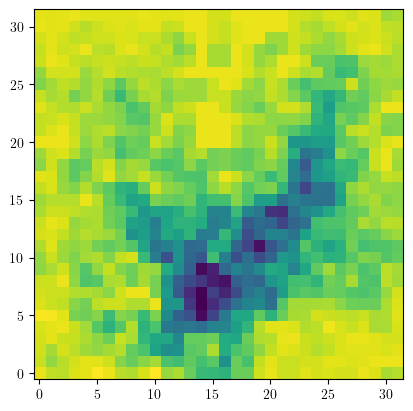

In [109]:
pl.figure()
# pl.imshow(np.log(np.abs(np.sum(delta_box_all_squeezed[indsort[2],...,3], axis=0))), origin='lower')
pl.imshow(((np.sum(delta_box_all_squeezed[indsort[2],...,10], axis=0))), origin='lower')
pl.show()



In [9]:
sdir = '/projects/bdne/spandey3/GOTHAM/prep_data/'
pk.dump(saved, open(f'{sdir}/test.pkl', 'wb'))



In [70]:
np.amin(pos_m_truth), np.amax(pos_m_truth)



(0.0, 24999.5)

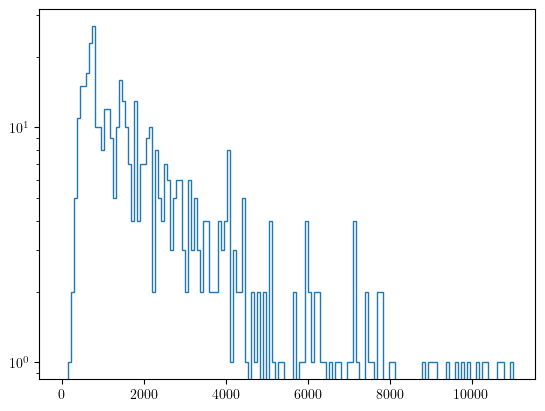

In [112]:
pl.figure()
_ = pl.hist(Npart.flatten(), bins=150, range=(0, 11000), histtype='step')
# _ = pl.hist(Npart_IC.flatten(), bins=150, range=(0, 11000), histtype='step')
pl.yscale('log')
pl.show()





In [403]:
# BoxSize = 1000.
# grid = 32
# nMax_h_IC = 2100
# dfpart_ngp_wxyz_IC = np.float32(np.zeros((grid, grid, grid, nMax_h_IC, 3)))
# NGP_xyz(np.float32(pos_m_truth_IC), dfpart_ngp_wxyz_IC, BoxSize)




In [404]:
# norm_delta = 1000
# if j1 == 0:
#     jn1 = grid - 1
# else:
#     jn1 = j1 - 1
# if j1 == grid - 1:
#     jp1 = 0
# else:
#     jp1 = j1 + 1

# jp1_all = [jn1, j1, jp1]

# if j2 == 0:
#     jn2 = grid - 1
# else:
#     jn2 = j2 - 1

# if j2 == grid - 1:
#     jp2 = 0
# else:
#     jp2 = j2 + 1

# jp2_all = [jn2, j2, jp2]

# if j3 == 0:
#     jn3 = grid - 1
# else:
#     jn3 = j3 - 1

# if j3 == grid - 1:
#     jp3 = 0
# else:
#     jp3 = j3 + 1

# jp3_all = [jn3, j3, jp3]

# coord_add_sign = [-1,0,1]
# # x_all_part = np.concatenate((dfpart_ngp_wxyz[j1,j2,j3], dfpart_ngp_wxyz[jp1,j2,j3], dfpart_ngp_wxyz[jn1,j2,j3], dfpart_ngp_wxyz[j1,jp2,j3], dfpart_ngp_wxyz[j1,jn2,j3], dfpart_ngp_wxyz[j1,j2,jp3], dfpart_ngp_wxyz[j1,j2,jn3]))
# # indpos = np.where(dfpart_ngp_wxyz[j1,j2,j3][:,0] != 0)[0]
# # print(indpos.shape)
# # all_part0 = dfpart_ngp_wxyz[j1,j2,j3][indpos,:]
# all_part = []
# for i1 in range(3):
#     for i2 in range(3):
#         for i3 in range(3):
#             all_part_here = dfpart_ngp_wxyz[jp1_all[i1],jp2_all[i2],jp3_all[i3]]
#             indpos = np.where(all_part_here[:,0] != 0)[0]
#             all_part_here = all_part_here[indpos,:]
#             all_part_here[:,0] = all_part_here[:,0] + coord_add_sign[i1]*BoxSize/(grid)
#             all_part_here[:,1] = all_part_here[:,1] + coord_add_sign[i2]*BoxSize/(grid)
#             all_part_here[:,2] = all_part_here[:,2] + coord_add_sign[i3]*BoxSize/(grid)

#             if len(all_part) == 0:
#                 all_part = all_part_here
#             else:
#                 all_part = np.vstack((all_part, all_part_here))

# grid_sbox = 64
# MAS = 'NGP'
# verbose = False

# box_size_sbox = BoxSize/(2*grid)
# all_part0_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
# all_part0 = all_part[all_part0_sel]
# delta_sbox0 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
# MASL.MA(all_part0 + box_size_sbox, delta_sbox0, (2*box_size_sbox), MAS, verbose=verbose)
# nbar0 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
# delta_sbox0 /= nbar0
# delta_sbox0 /= norm_delta


# box_size_sbox = 2*BoxSize/(2*grid)
# all_part1_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
# all_part1 = all_part[all_part1_sel]
# delta_sbox1 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
# MASL.MA(all_part1 + box_size_sbox, delta_sbox1, (2*box_size_sbox), MAS, verbose=verbose)
# nbar1 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
# delta_sbox1 /= nbar1
# delta_sbox1 /= norm_delta


# box_size_sbox = 3*BoxSize/(2*grid)
# all_part2 = all_part
# delta_sbox2 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
# MASL.MA(all_part2 + box_size_sbox, delta_sbox2, (2*box_size_sbox), MAS, verbose=verbose)
# nbar2 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
# delta_sbox2 /= nbar2
# delta_sbox2 /= norm_delta

# delta_sbox_all = np.stack((delta_sbox0, delta_sbox1, delta_sbox2))




In [405]:
# delta_sbox_all.shape


In [406]:
# pl.figure()
# _ = pl.hist(delta_sbox_all.flatten(), bins=1000, range=(0, 10), histtype='step', label='0')
# pl.yscale('log')
# # 1000**3


In [407]:
# np.amax(delta_sbox0), np.amax(delta_sbox1), np.amax(delta_sbox2)
# np.mean(delta_sbox0), np.mean(delta_sbox1), np.mean(delta_sbox2)



In [408]:
# # all_part0.shape, all_part1.shape, all_part2.shape, all_part3.shape, all_part4.shape, all_part5.shape, all_part6.shape, all_part.shape
# pl.figure()
# pl.imshow(np.sum(delta_sbox0[:,:,:], axis=0))
# pl.colorbar()



In [409]:
# # all_part0.shape, all_part1.shape, all_part2.shape, all_part3.shape, all_part4.shape, all_part5.shape, all_part6.shape, all_part.shape
# pl.figure()
# pl.imshow(np.sum(delta_sbox1[:,:,:], axis=0))
# pl.colorbar()


In [410]:
# # all_part0.shape, all_part1.shape, all_part2.shape, all_part3.shape, all_part4.shape, all_part5.shape, all_part6.shape, all_part.shape
# pl.figure()
# pl.imshow(np.sum(delta_sbox2[:,:,:], axis=0))
# pl.colorbar()


In [411]:
# all_part.shape
# x_all_part = all_part[:,0]
# y_all_part = all_part[:,1]
# z_all_part = all_part[:,2]

# ind_pos = np.where(x_all_part != -1000)[0]
# xyz_all = np.array([x_all_part[ind_pos], y_all_part[ind_pos], z_all_part[ind_pos]]).T

# np.amin(all_part), np.amax(all_part)



In [412]:
# xyz_all.shape,
# np.amin(xyz_all), np.amax(xyz_all)
# all_part + 1.5*(BoxSize/grid)


In [413]:
# grid_sbox = 32
# MAS = 'NGP'
# verbose = False
# delta_sbox = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
# MASL.MA(all_part + 1.5*(BoxSize/grid), delta_sbox, (3.*(BoxSize/grid)), MAS, verbose=verbose)


In [414]:
# pl.figure()
# pl.imshow(np.sum(delta_sbox[:,:,:], axis=0))


100%|██████████| 32/32 [01:39<00:00,  3.10s/it]


In [417]:
# from tqdm import tqdm
# norm_delta = 100           
# grid_sbox = 32
# MAS = 'NGP'
# verbose = False
# delta_box_all_IC = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 3))
# for j1 in tqdm(range(grid)):
#     for j2 in range(grid):
#         for j3 in range(grid):
            
#             if j1 == 0:
#                 jn1 = grid - 1
#             else:
#                 jn1 = j1 - 1
#             if j1 == grid - 1:
#                 jp1 = 0
#             else:
#                 jp1 = j1 + 1

#             jp1_all = [jn1, j1, jp1]

#             if j2 == 0:
#                 jn2 = grid - 1
#             else:
#                 jn2 = j2 - 1

#             if j2 == grid - 1:
#                 jp2 = 0
#             else:
#                 jp2 = j2 + 1

#             jp2_all = [jn2, j2, jp2]

#             if j3 == 0:
#                 jn3 = grid - 1
#             else:
#                 jn3 = j3 - 1

#             if j3 == grid - 1:
#                 jp3 = 0
#             else:
#                 jp3 = j3 + 1

#             jp3_all = [jn3, j3, jp3]

#             coord_add_sign = [-1,0,1]
#             all_part = []
#             for i1 in range(3):
#                 for i2 in range(3):
#                     for i3 in range(3):
#                         all_part_here = dfpart_ngp_wxyz_IC[jp1_all[i1],jp2_all[i2],jp3_all[i3]]
#                         indpos = np.where(all_part_here[:,0] != 0)[0]
#                         all_part_here = all_part_here[indpos,:]
#                         all_part_here[:,0] = all_part_here[:,0] + coord_add_sign[i1]*BoxSize/(grid)
#                         all_part_here[:,1] = all_part_here[:,1] + coord_add_sign[i2]*BoxSize/(grid)
#                         all_part_here[:,2] = all_part_here[:,2] + coord_add_sign[i3]*BoxSize/(grid)

#                         if len(all_part) == 0:
#                             all_part = all_part_here
#                         else:
#                             all_part = np.vstack((all_part, all_part_here))



#             box_size_sbox = BoxSize/(2*grid)
#             all_part0_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
#             all_part0 = all_part[all_part0_sel]
#             delta_sbox0 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part0 + box_size_sbox, delta_sbox0, (2*box_size_sbox), MAS, verbose=verbose)
#             nbar0 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
#             delta_sbox0 /= nbar0
#             delta_sbox0 /= norm_delta


#             box_size_sbox = 2*BoxSize/(2*grid)
#             all_part1_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
#             all_part1 = all_part[all_part1_sel]
#             delta_sbox1 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part1 + box_size_sbox, delta_sbox1, (2*box_size_sbox), MAS, verbose=verbose)
#             nbar1 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
#             delta_sbox1 /= nbar1
#             delta_sbox1 /= norm_delta


#             box_size_sbox = 3*BoxSize/(2*grid)
#             all_part2 = all_part
#             delta_sbox2 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part2 + box_size_sbox, delta_sbox2, (2*box_size_sbox), MAS, verbose=verbose)
#             nbar2 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
#             delta_sbox2 /= nbar2
#             delta_sbox2 /= norm_delta

#             delta_sbox_all_IC = np.stack((delta_sbox0, delta_sbox1, delta_sbox2))

#             # move first axis to last:
#             delta_sbox_all_IC = np.moveaxis(delta_sbox_all_IC, 0, -1)

#             delta_box_all_IC[j1,j2,j3] = delta_sbox_all_IC




In [418]:
# delta_box_all_squeezed_IC = np.reshape(delta_box_all_IC, (grid*grid*grid, grid_sbox, grid_sbox, grid_sbox, 3))



In [419]:
# np.amin(delta_box_all_squeezed_IC), np.amax(delta_box_all_squeezed_IC)




In [422]:
# dfhalo_ngp_wxyzM.shape


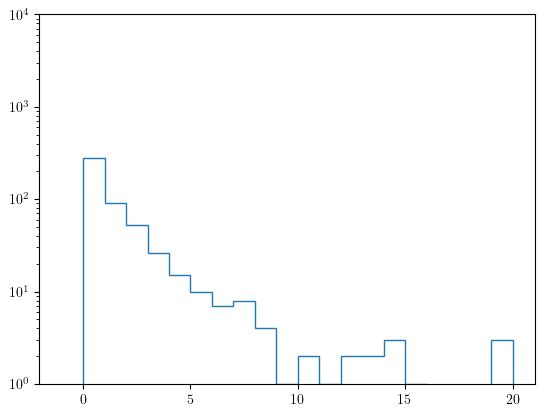

In [113]:
pl.figure()
# _ = pl.hist(Nhalos_truth.flatten(), bins=50, range=(0, 50), histtype='step')
_ = pl.hist(Nhalos_truth.flatten(), bins=21, range=(-1, 20), histtype='step')
pl.yscale('log')
pl.ylim(1, 1e4)
pl.show()





In [114]:
# dfhalo_ngp_xyzM_sorted_scaled[0,0,0,:,0]
np.amax(dfhalo_ngp_xyzM_sorted_scaled_digitized)



65

In [115]:
dfhalo_ngp_xyzM_tokenized[0,0,0,:]

array([ 0,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,
        1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,
        1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,
        1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,
        1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1,
       66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,
        1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,
        1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,
        1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,
        1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1,
       66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 66,  1,
        1,  1,  1, 66,  1,  1,  1,  1, 66,  1,  1,  1,  1, 65],
      dtype=int32)

In [118]:
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[:,50]


array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       66,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, 66,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, 66,  1,  1,  1,  1,  1,  1,  1, 65,  1,
        1,  1,  1,  1,  1, 66,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 66,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 66,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, 66, 66,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [119]:
# dfhalo_ngp_xyzM_tokenized_padded_ended
ind_empty = np.where(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[:,1] == end_token)[0]
ind_full = np.where(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[:,50] == end_token)[0]



In [120]:
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[ind_empty[0],:]
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[ind_full[0],:], dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[ind_full[0],:].shape




(array([ 0, 50, 28, 59, 20, 66, 45, 35, 37, 28, 66, 32, 40, 25, 59, 66, 22,
        20, 45, 15, 66, 19, 20, 45, 15, 66, 18, 26, 58, 21, 66, 17, 26, 42,
        28, 66, 12, 30, 60, 19, 66, 10, 28, 20, 40, 66,  5, 26, 15, 20, 65,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
       dtype=int32),
 (201,))

In [121]:
# np.min(np.sum(delta_box_all_squeezed[ind_empty[0],:,:,:,0], axis=0)), np.max(np.sum(delta_box_all_squeezed[ind_empty[0],:,:,:,0], axis=0))
np.min(np.sum(delta_box_all_squeezed[ind_full[0],:,:,:,0], axis=0)), np.max(np.sum(delta_box_all_squeezed[ind_full[0],:,:,:,0], axis=0))


(0.0, 3.4480000603944063)

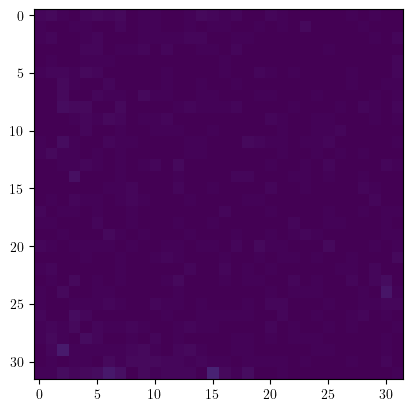

In [122]:
# delta_box_all_squeezed.shape
pl.figure()
pl.imshow(np.sum(delta_box_all_squeezed[ind_empty[0],:,:,:,0], axis=0), vmin=0, vmax=1.0)
pl.show()


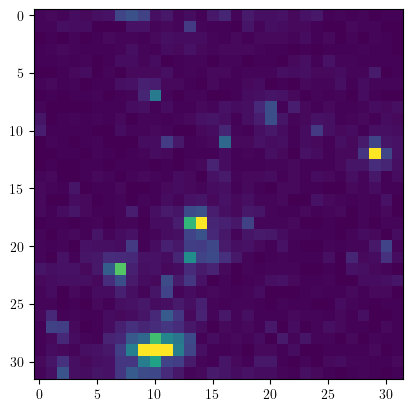

In [123]:
pl.figure()
pl.imshow(np.sum(delta_box_all_squeezed[ind_full[0],:,:,:,0], axis=0), vmin=0, vmax=1.0)
pl.show()


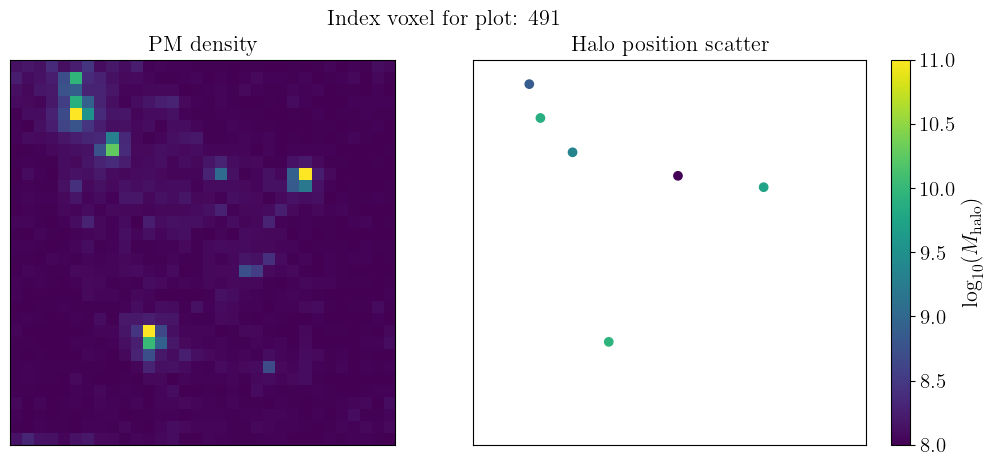

In [55]:
fig, (ax2, ax3) = pl.subplots(1, 2, figsize=(13, 5))

# indp = ind_full[0]
indsort = np.flip(np.argsort(np.mean(delta_box_all_squeezed[...,0], axis=(1,2,3))))
indp = indsort[5]
ax2.imshow(np.mean(delta_box_all_squeezed[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
ax2.set_title('PM density', size=16)
# pl.colorbar()
ax2.set_xticks([])
ax2.set_yticks([])

scatter = ax3.scatter(dfhalo_ngp_wxyzM_flatten[indp,:,1][:int(Nhalos_truth_flatten[indp])], dfhalo_ngp_wxyzM_flatten[indp,:,2][:int(Nhalos_truth_flatten[indp])], c=dfhalo_ngp_wxyzM_flatten[indp,:,3][:int(Nhalos_truth_flatten[indp])], cmap='viridis', vmin=prop_min, vmax=prop_max)
ax3.set_xlim(-xmin, xmin)
ax3.set_ylim(-xmin, xmin)
ax3.set_title('Halo position scatter', size=16)
ax3.set_xticks([])
ax3.set_yticks([])

cbar = pl.colorbar(scatter, ax=ax3)
cbar.set_label(r'$\log_{10}(M_{\rm halo})$', size=16)
cbar.ax.tick_params(labelsize=15)

pl.suptitle(f'Index voxel for plot: {indp}', size=16)
pl.subplots_adjust(wspace=0.05)
pl.show()




In [439]:
# facecolors.shape
# norm(density_data)

In [440]:
# import matplotlib.pyplot as plt
# import numpy as np
# from mpl_toolkits.mplot3d import Axes3D
# from matplotlib.colors import Normalize
# # Assume that ind_full, delta_box_all_squeezed, dfhalo_ngp_wxyzM_flatten, Nhalos_truth_flatten, and xmin are already defined

# fig = plt.figure(figsize=(11, 6))

# # 3D image plot
# ax2 = fig.add_subplot(121, projection='3d')
# indp = ind_full[0]
# x, y, z = np.indices(delta_box_all_squeezed[indp, :, :, :, 0].shape)

# density_data = delta_box_all_squeezed[indp, :, :, :, 0]
# voxels = density_data > 0.

# norm = Normalize(vmin=0.05, vmax=0.3)
# facecolors = plt.cm.viridis(norm(density_data))

# # alpha_values = norm(density_data)  # Using normalized density as alpha values

# # Set alpha values based on normalized density
# facecolors[..., -1] = (density_data/np.amax(density_data)) + (density_data/np.amax(density_data))**2

# ax2.voxels(voxels, facecolors=facecolors)

# # Create a ScalarMappable for the colorbar
# sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
# sm.set_array([])  # You can pass an empty array since we are setting the norm

# # Add the colorbar to the voxel plot
# cbar_voxel = plt.colorbar(sm, ax=ax2, shrink=0.5, aspect=15)
# cbar_voxel.set_label('Dark Matter Density', size=16)
# cbar_voxel.ax.tick_params(labelsize=14)


# # voxels = delta_box_all_squeezed[indp, :, :, :, 0] > 0.1
# # colors = np.zeros(voxels.shape + (4,))
# # colors[..., 0] = 1  # Red color
# # colors[..., -1] = 0.5  # Transparency

# # ax2.voxels(voxels, facecolors=colors, edgecolor='k')
# ax2.set_title('Sub-box PM density', size=16)
# ax2.set_xticks([])
# ax2.set_yticks([])
# ax2.set_zticks([])

# # 3D scatter plot
# ax3 = fig.add_subplot(122, projection='3d')
# # new_variable = np.random.uniform(13, 15.5, size=int(Nhalos_truth_flatten[indp]))
# scatter = ax3.scatter(dfhalo_ngp_wxyzM_flatten[indp, :, 0][:int(Nhalos_truth_flatten[indp])],
#                       dfhalo_ngp_wxyzM_flatten[indp, :, 1][:int(Nhalos_truth_flatten[indp])],
#                       dfhalo_ngp_wxyzM_flatten[indp, :, 2][:int(Nhalos_truth_flatten[indp])],
#                       c=dfhalo_ngp_wxyzM_flatten[indp,:,3][:int(Nhalos_truth_flatten[indp])], cmap='viridis', vmin=13, vmax=14.5, s=12)
# ax3.set_xlim(-xmin, xmin)
# ax3.set_ylim(-xmin, xmin)
# ax3.set_zlim(-xmin, xmin)
# ax3.set_title('Sub-box Halo position', size=16)
# ax3.set_xticks([])
# ax3.set_yticks([])
# ax3.set_zticks([])
# # ax3.set_xlabel(r'(Box Size)/32')

# # Add a color bar to show the color scale
# cbar = plt.colorbar(scatter, ax=ax3, shrink=0.5, aspect=15)
# # cbar.set_label('New Variable (13 to 15.5)')
# cbar.set_label(r'$\log_{10}({\rm Halo \, Mass})$', size=16)
# cbar.ax.tick_params(labelsize=15)

# # plt.suptitle(f'Index voxel for plot: {indp}', size=16)

# # Adjust the spacing between the left and right plots
# plt.subplots_adjust(wspace=0.4)  # Adjust the wspace parameter as needed

# plt.tight_layout()
# # plt.show()
# plt.savefig(f'3D_PM_density_halo_position_isim_{isim_fid}.png', dpi=300, bbox_inches='tight')



In [441]:
# np.amin(alpha_values), np.amax(alpha_values)
np.amin(density_data), np.amax(density_data)



(0.0, 0.9860740900039673)

In [442]:
# indp = ind_full[0]

# fig, (ax1, ax2, ax3) = pl.subplots(1, 3, figsize=(18, 5))

# ax1.imshow(np.sum(delta_box_all_squeezed_IC[indp,:,:,:,2], axis=0).T, origin='lower', vmin=0.0, vmax=0.1)
# ax1.set_title('Quijote density', size=16)
# # ax1.imshow(np.sum(delta_box_all_squeezed_1[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
# # ax1.set_title('Quijote density', size=16)
# # ax1.colorbar()
# # indp = ind_empty[0]
# ax2.imshow(np.sum(delta_box_all_squeezed[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
# ax2.set_title('PM density', size=16)
# # pl.colorbar()

# ax3.scatter(dfhalo_ngp_wxyzM_flatten[indp,:,1][:int(Nhalos_truth_flatten[indp])], dfhalo_ngp_wxyzM_flatten[indp,:,2][:int(Nhalos_truth_flatten[indp])])
# ax3.set_xlim(-xmin, xmin)
# ax3.set_ylim(-xmin, xmin)
# ax3.set_title('Halo position scatter', size=16)

# pl.suptitle(f'Index voxel for plot: {indp}', size=16)




In [443]:
# start_token = 0
# pad_token = 1
# end_token = nvocab + 1
# space_token = nvocab + 2
# max_sentence_length = 1 + nMax_h*4 + 1 + (nMax_h-1)


In [444]:
# max_sentence_length
# np.amax(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed), np.amin(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed)
# nvocab + 3

# nvocab + 3

# Do some sanity checks:


In [119]:
df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/df_halo_part_ngp_xyzM_tokenized_density3Dgrid_32_isim_1_snap_3.pkl','rb'))

dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_1 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
dfhalo_ngp_wxyzM_1 = df['dfhalo_ngp_wxyzM']
Nhalos_truth_1 = df['Nhalos_truth']
delta_box_all_squeezed_1= df['delta_box_all_squeezed']



In [127]:
Nhalos_truth_flatten = np.reshape(Nhalos_truth, (grid*grid*grid,))


In [128]:
# Nhalos_truth_flatten[0]


5.0

In [111]:
# dfhalo_ngp_wxyzM[0,0,0,:,0]
dfhalo_ngp_wxyzM_flatten = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))



In [153]:
# delta_box_all_squeezed.shape, dfhalo_ngp_wxyzM_flatten.shape

indp = 90


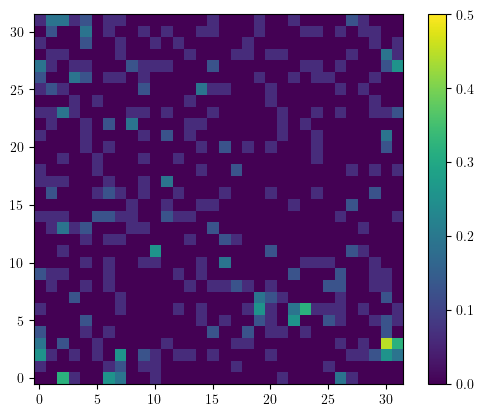

In [154]:
pl.figure()
pl.imshow(np.sum(delta_box_all_squeezed_1[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
pl.colorbar()


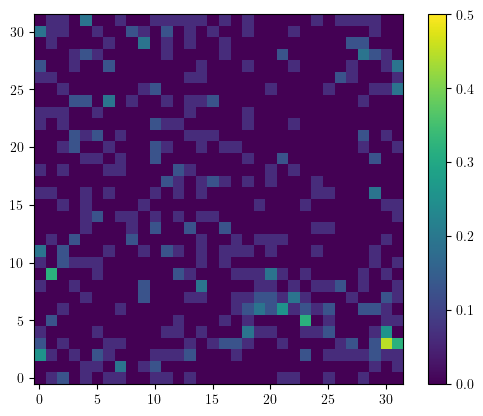

In [155]:
pl.figure()
pl.imshow(np.sum(delta_box_all_squeezed[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
pl.colorbar()




(-15.625, 15.625)

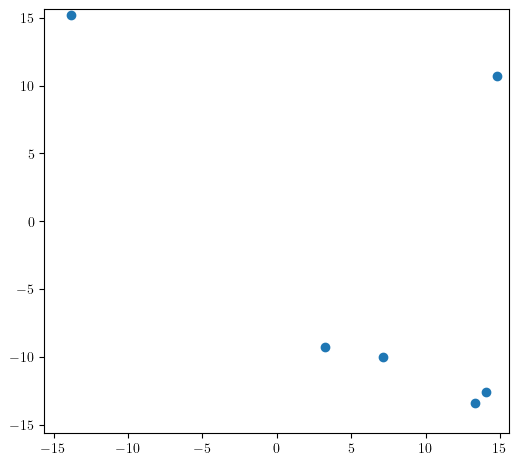

In [156]:
pl.figure(figsize=(6,5.5))
pl.scatter(dfhalo_ngp_wxyzM_flatten[indp,:,1][:int(Nhalos_truth_flatten[indp])], dfhalo_ngp_wxyzM_flatten[indp,:,2][:int(Nhalos_truth_flatten[indp])])
pl.xlim(-xmin, xmin)
pl.ylim(-xmin, xmin)


Text(0.5, 0.98, 'Index voxel for plot: 90')

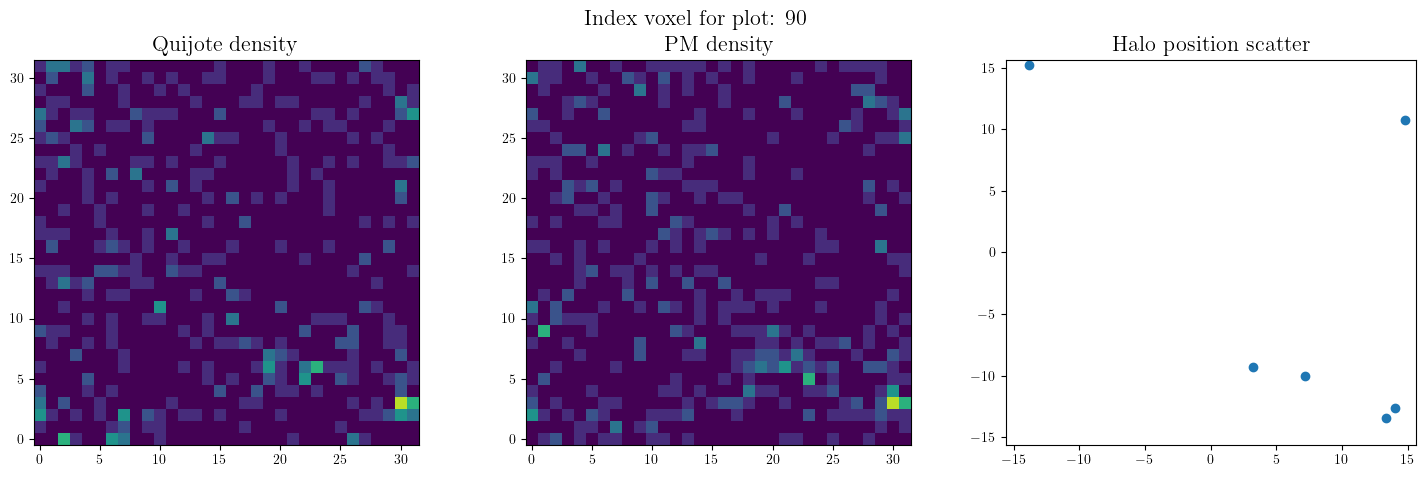

In [157]:
fig, (ax1, ax2, ax3) = pl.subplots(1, 3, figsize=(18, 5))

ax1.imshow(np.sum(delta_box_all_squeezed_1[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
ax1.set_title('Quijote density', size=16)
# ax1.colorbar()

ax2.imshow(np.sum(delta_box_all_squeezed[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
ax2.set_title('PM density', size=16)
# pl.colorbar()

ax3.scatter(dfhalo_ngp_wxyzM_flatten[indp,:,1][:int(Nhalos_truth_flatten[indp])], dfhalo_ngp_wxyzM_flatten[indp,:,2][:int(Nhalos_truth_flatten[indp])])
ax3.set_xlim(-xmin, xmin)
ax3.set_ylim(-xmin, xmin)
ax3.set_title('Halo position scatter', size=16)

pl.suptitle(f'Index voxel for plot: {indp}', size=16)



In [136]:
xmin


15.625

In [ ]:
# pl.figure()
# pl.imshow(np.sum(delta_sbox0[:,:,:], axis=0))
# pl.colorbar()



# save to disk in binary format to easy reading with memmap:


In [12]:
# _nvocab64_Mmin_1e13p5
# df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_0_snap_3_FINAL.pkl','rb'))
# df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_0_snap_3_nvocab64_Mmin_1e13p5.pkl','rb'))
df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_0_snap_3_nvocab64.pkl','rb'))

dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
dfhalo_ngp_wxyzM_0 = df['dfhalo_ngp_wxyzM']
Nhalos_truth_0 = df['Nhalos_truth']
delta_box_all_squeezed_0 = df['delta_box_all_squeezed']


# df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_1_snap_3_FINAL.pkl','rb'))
# df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_1_snap_3_nvocab64_Mmin_1e13p5.pkl','rb'))
df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_1_snap_3_nvocab64.pkl','rb'))

dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_1 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
dfhalo_ngp_wxyzM_1 = df['dfhalo_ngp_wxyzM']
Nhalos_truth_1 = df['Nhalos_truth']
delta_box_all_squeezed_1= df['delta_box_all_squeezed']


# df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_2_snap_3_FINAL.pkl','rb'))
# df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_2_snap_3_nvocab64_Mmin_1e13p5.pkl','rb'))
df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_2_snap_3_nvocab64.pkl','rb'))
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_2 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
dfhalo_ngp_wxyzM_2 = df['dfhalo_ngp_wxyzM']
Nhalos_truth_2 = df['Nhalos_truth']
delta_box_all_squeezed_2 = df['delta_box_all_squeezed']




In [13]:
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = np.vstack((dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0, dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_1, dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_2)).astype(np.int16)





In [14]:
delta_box_all_squeezed_all = np.vstack((delta_box_all_squeezed_0, delta_box_all_squeezed_1, delta_box_all_squeezed_2)).astype(np.float32)
delta_box_all_squeezed_all = np.moveaxis(delta_box_all_squeezed_all, -1, 1)


In [15]:
nMax_h = df['nMax_h']
grid = df['grid']


In [16]:
grid = dfhalo_ngp_wxyzM_0.shape[0]
dfhalo_ngp_wxyzM_0_reshape = np.reshape(dfhalo_ngp_wxyzM_0, (grid*grid*grid, nMax_h, 4))
dfhalo_ngp_wxyzM_1_reshape = np.reshape(dfhalo_ngp_wxyzM_1, (grid*grid*grid, nMax_h, 4))
dfhalo_ngp_wxyzM_2_reshape = np.reshape(dfhalo_ngp_wxyzM_2, (grid*grid*grid, nMax_h, 4))
dfhalo_ngp_wxyzM_reshape_all = np.vstack((dfhalo_ngp_wxyzM_0_reshape, dfhalo_ngp_wxyzM_1_reshape, dfhalo_ngp_wxyzM_2_reshape)).astype(np.float32)



In [17]:
Nhalos_truth_0_reshape = np.reshape(Nhalos_truth_0, (grid*grid*grid))
Nhalos_truth_1_reshape = np.reshape(Nhalos_truth_1, (grid*grid*grid))
Nhalos_truth_2_reshape = np.reshape(Nhalos_truth_2, (grid*grid*grid))
Nhalos_truth_reshape_all = np.concatenate((Nhalos_truth_0_reshape, Nhalos_truth_1_reshape, Nhalos_truth_2_reshape)).astype(np.int16)



In [18]:
        # 'nvocab_total': nvocab + 3,
        # 'max_sentence_length': max_sentence_length,
        # 'grid': grid,
        # 'nMax_h': nMax_h,
        # 'BoxSize': BoxSize,
        # 'lgMin': lgMin,
        # 'lgMax': lgMax,
        # 'xmin': xmin,
        # 'norm_delta': norm_delta,
        # 'start_token': start_token,
        # 'pad_token': pad_token,
        # 'end_token': end_token,
        # 'space_token': space_token


In [19]:
# save using h5py
import h5py as h5
# f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_FINAL.h5', 'w')
# f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_nvocab64_Mmin_13p5.h5', 'w')
f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_nvocab64_Mmin_13p0.h5', 'w')
f.create_dataset('dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all', data=dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all)
f.create_dataset('delta_box_all_squeezed_all', data=delta_box_all_squeezed_all)
f.create_dataset('dfhalo_ngp_wxyzM_reshape_all', data=dfhalo_ngp_wxyzM_reshape_all)
f.create_dataset('Nhalos_truth_reshape_all', data=Nhalos_truth_reshape_all)
f.create_dataset('nvocab_total', data=df['nvocab_total'])
f.create_dataset('max_sentence_length', data=df['max_sentence_length'])
f.create_dataset('grid', data=df['grid'])
f.create_dataset('nMax_h', data=df['nMax_h'])
f.create_dataset('BoxSize', data=df['BoxSize'])
f.create_dataset('lgMin', data=df['lgMin'])
f.create_dataset('lgMax', data=df['lgMax'])
f.create_dataset('xmin', data=df['xmin'])
f.create_dataset('norm_delta', data=df['norm_delta'])
f.create_dataset('start_token', data=df['start_token'])
f.create_dataset('pad_token', data=df['pad_token'])
f.create_dataset('end_token', data=df['end_token'])
f.create_dataset('space_token', data=df['space_token'])
f.close()




In [11]:
df['max_sentence_length'], df['nvocab_total'], df['grid'], df['nMax_h'], df['BoxSize'], df['lgMin'], df['lgMax'], df['xmin'], df['norm_delta'], df['start_token'], df['pad_token'], df['end_token'], df['space_token']



(101, 67, 32, 20, 1000.0, 13.5, 15.5, 15.625, 1000, 0, 1, 65, 66)

In [20]:
df['max_sentence_length'], df['nvocab_total'], df['grid'], df['nMax_h'], df['BoxSize'], df['lgMin'], df['lgMax'], df['xmin'], df['norm_delta'], df['start_token'], df['pad_token'], df['end_token'], df['space_token']




(211, 67, 32, 42, 1000.0, 13.0, 15.5, 15.625, 1000, 0, 1, 65, 66)

In [14]:
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all.shape
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0.shape
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all.dtype
sdir = '/mnt/home/spandey/ceph/CHARFORMER/data/'
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all.tofile(sdir + 'dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_isim_0_to_2.bin')



In [16]:
# delta_box_all_squeezed_2.shape
delta_box_all_squeezed_all = np.vstack((delta_box_all_squeezed_0, delta_box_all_squeezed_1, delta_box_all_squeezed_2))
delta_box_all_squeezed_all = np.moveaxis(delta_box_all_squeezed, -1, 1)
delta_box_all_squeezed_all.shape


: 

In [ ]:
delta_box_all_squeezed_all.tofile(sdir + 'dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_isim_0_to_2.bin')



In [ ]:
dfhalo_ngp_wxyzM_all = np.vstack((dfhalo_ngp_wxyzM_0, dfhalo_ngp_wxyzM_1, dfhalo_ngp_wxyzM_2))
print(dfhalo_ngp_wxyzM_all.shape)



In [ ]:
dfhalo_ngp_wxyzM_reshape_all = np.vstack((dfhalo_ngp_wxyzM_0_reshape, dfhalo_ngp_wxyzM_1_reshape, dfhalo_ngp_wxyzM_2_reshape))

In [ ]:
Nhalos_truth_reshape_all = np.concatenate((Nhalos_truth_0_reshape, Nhalos_truth_1_reshape, Nhalos_truth_2_reshape))



In [ ]:
dfhalo_ngp_wxyzM_reshape_all.tofile(sdir + 'dfhalo_ngp_wxyzM_reshape_all_squeezed_isim_0_to_2.bin')




In [ ]:
# Nhalos_truth_0_reshape = np.reshape(Nhalos_truth_0.shape, (grid*grid*grid))
Nhalos_truth_reshape_all.tofile(sdir + 'Nhalos_truth_reshape_all_squeezed_isim_0_to_2.bin')


In [1]:
import numpy as np
import h5py as h5

f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/df_halo_part_ngp_xyzM_tokenized_density3Dgrid_32_isim_012_snap_3.h5', 'r')
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = f['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all'][:]
delta_box_all_squeezed_all = f['delta_box_all_squeezed_all'][:]
f.close()






In [3]:
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all.shape



(98304, 161)

In [4]:
delta_box_all_squeezed_all.shape



(98304, 3, 32, 32, 32)

In [19]:
inp = "dztz"
s_inp = [[0,0,0],[1,1,1]]

chars_inp = list(inp)

all_chars_eng = list('abcdefghijklmnopqrstuvwxyz')
dict_pos_to_char = {}
for i in range(len(all_chars_eng)):
    dict_pos_to_char[i] = all_chars_eng[i]

dict_char_to_pos = {}
for i in range(len(all_chars_eng)):
    dict_char_to_pos[all_chars_eng[i]] = i

char_array_inp = []
for i in range(len(chars_inp)):
    char_array_inp.append(dict_char_to_pos[chars_inp[i]])

count_arr = []
for i in range(len(chars_inp)):
    count_arr.append(0)

for js in range(len(s_inp)):
    i1 = s_inp[js][0]
    i2 = s_inp[js][1]+1
    dv = s_inp[js][2]
    if dv == 0:
        count_arr[i1:i2] = [x - 1 for x in count_arr[i1:i2]]
    else:
        count_arr[i1:i2] = [x + 1 for x in count_arr[i1:i2]]



count_arr_f = []
for i in range(len(count_arr)):
    count_arr_f.append((char_array_inp[i] + count_arr[i])%26)

chars_out = []
for i in range(len(count_arr_f)):
    chars_out.append(dict_pos_to_char[count_arr_f[i]])

str_out = ''.join(chars_out)
print(str_out)


catz


In [22]:
# count_arr[i1:i2]



In [7]:
# np.mod(-2, 24)
-1%26

25